# Analysis: notes

### steps
1. Data preparation
     1. pandas to load data + inspect/lint
     2. prepare columns
     3. prepare string encodings

Encodings = MLE, see encoded_test_data.csv

2. Model preparation
   1.  load all-mpnet-base-v2 model via sentence-transformers library

3. Embeddings
     1. encode() source and target questions
     2. source_embedding, target_embedding *columns*
     3. error handling ?!

4. Similarity
     1. cosine for source and target embeddings per pair
     2. similarity_score *column*

### notes

Start with a data set containing feature encodings, which are binary values that indicate whether an indexed example has certain features from our feature set. These were created via MultiLabelBinarize from url: . See main.py

The next step is to generate model embeddings. These are usually dense numerical vectors that represent the meaning of a text. In this project I used the url: for model + model card, either paraphrase-multilingual-MiniLM-L12-v2 or LaBSE

For our particular task, we want to generate two sets of embeddings, one for non-english question(source) and one of the english question (target)

In [2]:
# import the required libraries
from sentence_transformers import SentenceTransformer # loads the model and generates embeddings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm
from scipy import stats



In [25]:
# 1. Load data from data/encoded_test_data.csv

data = pd.read_csv('data/encoded_test_data.csv')

# 2. Load model from sentence transformers
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


In [26]:
# generate embeddings for all examples in the data, one embedding per source question and one embedding per target question

print("Generating embeddings for source questions...")
source_embeddings = model.encode(data['source'].tolist(), show_progress_bar=True)

print('Generating embeddings for target questions...')
target_embeddings = model.encode(data['target'].tolist(), show_progress_bar=True)

# uncomment below print statements to see what the embeddings look like, ndim vector; only print one embedding at a time because of size issues

# print(f'source embedding:{source_embeddings[0]}')
# print(f'target embedding:{target_embeddings[0]}')

np.save('source_embeddings_miniLM.npy', source_embeddings)
np.save('target_embeddings_miniLM.npy', target_embeddings)




Generating embeddings for source questions...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Generating embeddings for target questions...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [27]:
# calculate cosine similarity of all examples
similarities = []
for s_emb, t_emb in tqdm(zip(source_embeddings, target_embeddings)):
    sim = np.dot(s_emb, t_emb) / (np.linalg.norm(s_emb) * np.linalg.norm(t_emb))
    similarities.append(sim)


# augment the original data with the sim scores

data['cosine_similarity'] = similarities

data.to_csv('questions_similarities.csv')

print('Results of similarity analysis:')
print(data['cosine_similarity'].describe())

print("\nExample pairs from different similarity ranges:")
# high similarity
high_idx = np.argmax(similarities)
print(f"\nHighest similarity ({similarities[high_idx]:.3f}):")
print(f"Source ({data.iloc[high_idx]['language']}): {data.iloc[high_idx]['source']}")
print(f"Target: {data.iloc[high_idx]['target']}")

# medium similarity
med_idx = np.argsort(similarities)[len(similarities)//2]
print(f"\nMedian similarity ({similarities[med_idx]:.3f}):")
print(f"Source ({data.iloc[med_idx]['language']}): {data.iloc[med_idx]['source']}")
print(f"Target: {data.iloc[med_idx]['target']}")

# low similarity
low_idx = np.argmin(similarities)
print(f"\nLowest similarity ({similarities[low_idx]:.3f}):")
print(f"Source ({data.iloc[low_idx]['language']}): {data.iloc[low_idx]['source']}")
print(f"Target: {data.iloc[low_idx]['target']}")

# save just the data with similarities (not the big embeddings)
data.to_csv('questions_with_similarities_miniLM.csv')
print("\nSaved data with new similarities!")


500it [00:00, 16977.83it/s]

Results of similarity analysis:
count    500.000000
mean       0.843210
std        0.143460
min        0.106340
25%        0.784217
50%        0.896104
75%        0.943204
max        0.988594
Name: cosine_similarity, dtype: float64

Example pairs from different similarity ranges:

Highest similarity (0.989):
Source (id): Tetapi, bagaimana jika kita berpikir tentang makanan sebagai cara untuk benar-benar belajar lebih banyak tentang karyawan kita?
Target: But what if we thought about food as a way to really learn more about our employees?

Median similarity (0.896):
Source (id): Aku tidak membangun tempat ini, tapi ini semua adalah warisan ku …. hmmm, tempat ini adalah apa yang orang tua ku tinggalkan untuk ku, jadi apa jawaban mu?
Target: I did not construct this place, but it is all of my inheritance….hmmm, this place is what my parents left for me, so what’s your answer?

Lowest similarity (0.106):
Source (mr): आपण हे खरेदी करू शकता तेव्हा आम्हाला आपल्या स्वतः च्या हातांनी मत्स्यालय 

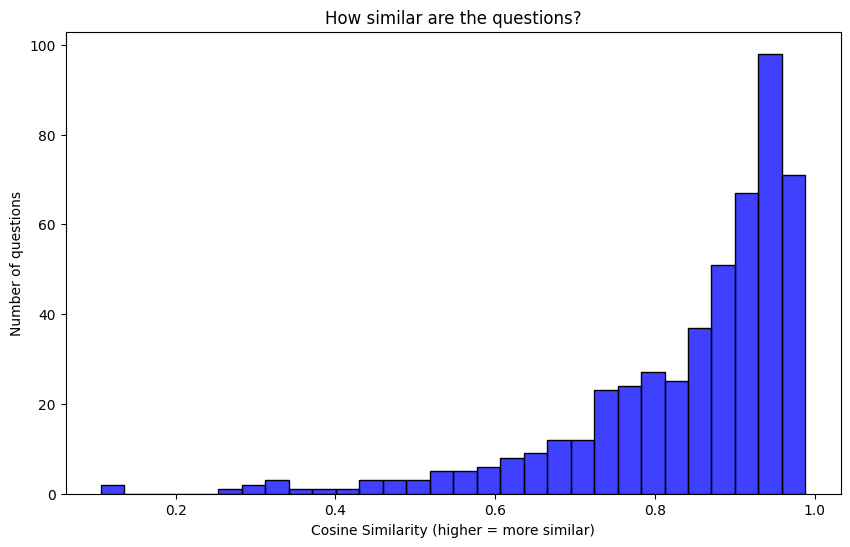

In [28]:
#visualizations

#similarity analysis
plt.figure(figsize=(10, 6))  # make the plot bigger
sns.histplot(data=data, x='cosine_similarity', bins=30, color='blue')  # i like blue
plt.title('How similar are the questions?')
plt.xlabel('Cosine Similarity (higher = more similar)')
plt.ylabel('Number of questions')
plt.show()

## Testing Individual Hypotheses



In [58]:
data = pd.read_csv('questions_with_similarities_miniLM.csv')

In [47]:
# H3: Negation in Arabic vs other languages
print("\nH3: Negation Effect by Language")
for lang in data['language'].unique():
    neg = data[(data['language'] == lang) & (data['f1_negation'] == 1)]['cosine_similarity']
    non_neg = data[(data['language'] == lang) & (data['f1_negation'] == 0)]['cosine_similarity']
    print(f"\n{lang.upper()}:")
    print(f"With negation: {neg.mean():.3f} ± {neg.std():.3f} (n={len(neg)})")
    print(f"Without negation: {non_neg.mean():.3f} ± {non_neg.std():.3f} (n={len(non_neg)})")
    if len(neg) > 0 and len(non_neg) > 0:
        t_stat, p_val = stats.ttest_ind(neg, non_neg)
        print(f"T-test p-value: {p_val:.4f}")



H3: Negation Effect by Language

AF:
With negation: 0.791 ± 0.086 (n=43)
Without negation: 0.835 ± 0.109 (n=73)
T-test p-value: 0.0245

ID:
With negation: 0.932 ± 0.046 (n=25)
Without negation: 0.930 ± 0.042 (n=113)
T-test p-value: 0.8393

MR:
With negation: 0.763 ± 0.142 (n=53)
Without negation: 0.700 ± 0.205 (n=84)
T-test p-value: 0.0506

AR:
With negation: 0.919 ± 0.049 (n=20)
Without negation: 0.905 ± 0.083 (n=89)
T-test p-value: 0.4563


In [17]:
# + H4: Cleft constructions and polar questions, to make this representable add cotrast with cleft propositions that are other question types
""" 
@500: 
Cleft questions that are polar: 11.1%
Total cleft questions: 36
"""
print("H4: Cleft and Polar Questions Analysis")
cleft_polar = len(data[(data['f1_cleft_wh'] == 1) & (data['f2_polar'] == 1)])
total_cleft = len(data[data['f1_cleft_wh'] == 1])
print(f"\nCleft questions that are polar: {cleft_polar/total_cleft*100:.1f}%")
print(f"Total cleft questions: {total_cleft}")


H4: Cleft and Polar Questions Analysis

Cleft questions that are polar: 11.1%
Total cleft questions: 36


In [53]:
# +- H7: Cleft-WH + Alternative, very similar to H4[cleft+polar]
""" 
@500: only 3 samples, mean: 0.936 ± 0.03 (complex structures are rare after all)
"""
print("\nH7: Cleft-WH and Alternative Questions")
cleft_alt = data[(data['f1_cleft_wh'] == 1) & (data['f2_alternative'] == 1)]['cosine_similarity']
only_cleft = data[(data['f1_cleft_wh'] == 1) & (data['f2_alternative'] == 0)]['cosine_similarity']
only_alt = data[(data['f1_cleft_wh'] == 0) & (data['f2_alternative'] == 1)]['cosine_similarity']

print("\nBoth cleft and alternative:")
print(f"Mean: {cleft_alt.mean():.3f} ± {cleft_alt.std():.3f}")
print(f"Count: {len(cleft_alt)}")




H7: Cleft-WH and Alternative Questions

Both cleft and alternative:
Mean: 0.936 ± 0.036
Count: 3


In [ ]:
# new H7:Cleft and Alternative Questions


# Load data
data = pd.read_csv('questions_with_similarities_miniLM.csv')


print("\nH7: Cleft and Alternative Questions")
print("Theory: Cleft constructions are structurally incompatible with alternative questions")
print("due to conflicting information structure requirements.")

# Calculate overall frequencies
total_clefts = (data['f1_cleft_wh'] == 1).sum()
total_alternatives = (data['f2_alternative'] == 1).sum()
cleft_alt_combo = ((data['f1_cleft_wh'] == 1) & (data['f2_alternative'] == 1)).sum()

# Calculate expected co-occurrence under independence
expected_combo = (total_clefts * total_alternatives) / len(data)

print("\nFrequency Analysis:")
print(f"Total cleft questions: {total_clefts}")
print(f"Total alternative questions: {total_alternatives}")
print(f"Actual co-occurrences: {cleft_alt_combo}")
print(f"Expected co-occurrences: {expected_combo:.2f}")

# Chi-square test
contingency_table = pd.crosstab(data['f1_cleft_wh'], data['f2_alternative'])
chi2, p_value = stats.chi2_contingency(contingency_table)[:2]
print(f"\nChi-square test p-value: {p_value:.4f}")

# Similarity analysis when they do co-occur
if cleft_alt_combo > 0:
    combo_sims = data[(data['f1_cleft_wh'] == 1) & (data['f2_alternative'] == 1)]['cosine_similarity']
    regular_sims = data[(data['f1_cleft_wh'] == 0) & (data['f2_alternative'] == 0)]['cosine_similarity']
    
    print("\nSimilarity Analysis:")
    print(f"Mean similarity for co-occurring cases: {combo_sims.mean():.3f} ± {combo_sims.std():.3f}")
    print(f"Mean similarity for regular cases: {regular_sims.mean():.3f} ± {regular_sims.std():.3f}")

# Language-specific analysis
print("\nLanguage-specific patterns:")
for lang in data['language'].unique():
    lang_data = data[data['language'] == lang]
    lang_combo = ((lang_data['f1_cleft_wh'] == 1) & 
                  (lang_data['f2_alternative'] == 1)).sum()
    total_lang_clefts = (lang_data['f1_cleft_wh'] == 1).sum()
    
    print(f"\n{lang}:")
    print(f"Cleft questions: {total_lang_clefts}")
    print(f"Cleft + Alternative: {lang_combo}")

# Visualizations
plt.figure(figsize=(15, 5))

# Plot 1: Co-occurrence heatmap
plt.subplot(1, 3, 1)
heatmap_data = pd.crosstab(data['f1_cleft_wh'], data['f2_alternative'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Cleft vs Alternative Co-occurrence')
plt.xlabel('Alternative Question')
plt.ylabel('Cleft Construction')

# Plot 2: Similarity distribution comparison
plt.subplot(1, 3, 2)
if cleft_alt_combo > 0:
    data['group'] = 'Regular'
    data.loc[(data['f1_cleft_wh'] == 1) & (data['f2_alternative'] == 1), 'group'] = 'Cleft+Alt'
    sns.boxplot(data=data, x='group', y='cosine_similarity')
    plt.title('Similarity Distributions')

# Plot 3: Language-specific patterns
plt.subplot(1, 3, 3)
lang_stats = []
for lang in data['language'].unique():
    lang_data = data[data['language'] == lang]
    lang_stats.append({
        'language': lang,
        'cleft_ratio': (lang_data['f1_cleft_wh'] == 1).mean(),
        'alt_ratio': (lang_data['f2_alternative'] == 1).mean()
    })
lang_df = pd.DataFrame(lang_stats)
lang_df.plot(x='language', kind='bar', width=0.8)
plt.title('Feature Distribution by Language')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Predictions check
predictions = {
    'strong': cleft_alt_combo == 0,  # Strong: No co-occurrence
    'medium': cleft_alt_combo < expected_combo * 0.5,  # Medium: Less than half expected
    'weak': cleft_alt_combo < expected_combo  # Weak: Less than expected
}

print("\nPrediction Results:")
for level, result in predictions.items():
    print(f"{level.capitalize()} prediction {'supported' if result else 'not supported'}")

In [54]:
# + H8: Cleft constructions by language
""" 
AF:Mean: 0.787 ± 0.116 Count: 12, ID:Mean: 0.932 ± 0.044 Count: 10, 
MR:Mean: 0.571 ± 0.267 Count: 6, AR:Mean: 0.925 ± 0.032 Count: 8

"""

print("\nH8: Cleft Constructions by Language")
for lang in data['language'].unique():
    cleft_lang = data[(data['language'] == lang) & (data['f1_cleft_wh'] == 1)]['cosine_similarity']
    if len(cleft_lang) > 0:
        print(f"\n{lang.upper()}:")
        print(f"Mean: {cleft_lang.mean():.3f} ± {cleft_lang.std():.3f}")
        print(f"Count: {len(cleft_lang)}")




H8: Cleft Constructions by Language

AF:
Mean: 0.787 ± 0.116
Count: 12

ID:
Mean: 0.932 ± 0.044
Count: 10

MR:
Mean: 0.571 ± 0.267
Count: 6

AR:
Mean: 0.925 ± 0.032
Count: 8


Analyzing feature co-occurrences...


C:\Users\robin\AppData\Local\Temp\ipykernel_19612\1322545558.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.064' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  co_occurrence.loc[f1, f2] = both_present / either_present
C:\Users\robin\AppData\Local\Temp\ipykernel_19612\1322545558.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0539568345323741' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  co_occurrence.loc[f1, f2] = both_present / either_present
C:\Users\robin\AppData\Local\Temp\ipykernel_19612\1322545558.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.047337278106508875' has dtype incompatible with int64, please explicitly cast to a com


Rarest feature combinations:

Rare feature combinations and their similarities:
f1_cleft_wh + f1_comparison:
  Count: 8 (1.6%)
  Mean similarity: 0.821
f1_cleft_wh + f1_negation:
  Count: 8 (1.6%)
  Mean similarity: 0.746
f1_cleft_wh + f1_quantification:
  Count: 10 (2.0%)
  Mean similarity: 0.830
f1_comparison + f1_quantification:
  Count: 12 (2.4%)
  Mean similarity: 0.808
f1_comparison + f1_negation:
  Count: 14 (2.8%)
  Mean similarity: 0.788
f1_cleft_wh + f1_modality:
  Count: 15 (3.0%)
  Mean similarity: 0.858
f2_conditional + f2_conditional:
  Count: 15 (3.0%)
  Mean similarity: 0.836
f1_negation + f1_quantification:
  Count: 21 (4.2%)
  Mean similarity: 0.831
f2_alternative + f2_alternative:
  Count: 21 (4.2%)
  Mean similarity: 0.892


C:\Users\robin\AppData\Local\Temp\ipykernel_19612\1322545558.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rare_similarities, labels=labels)


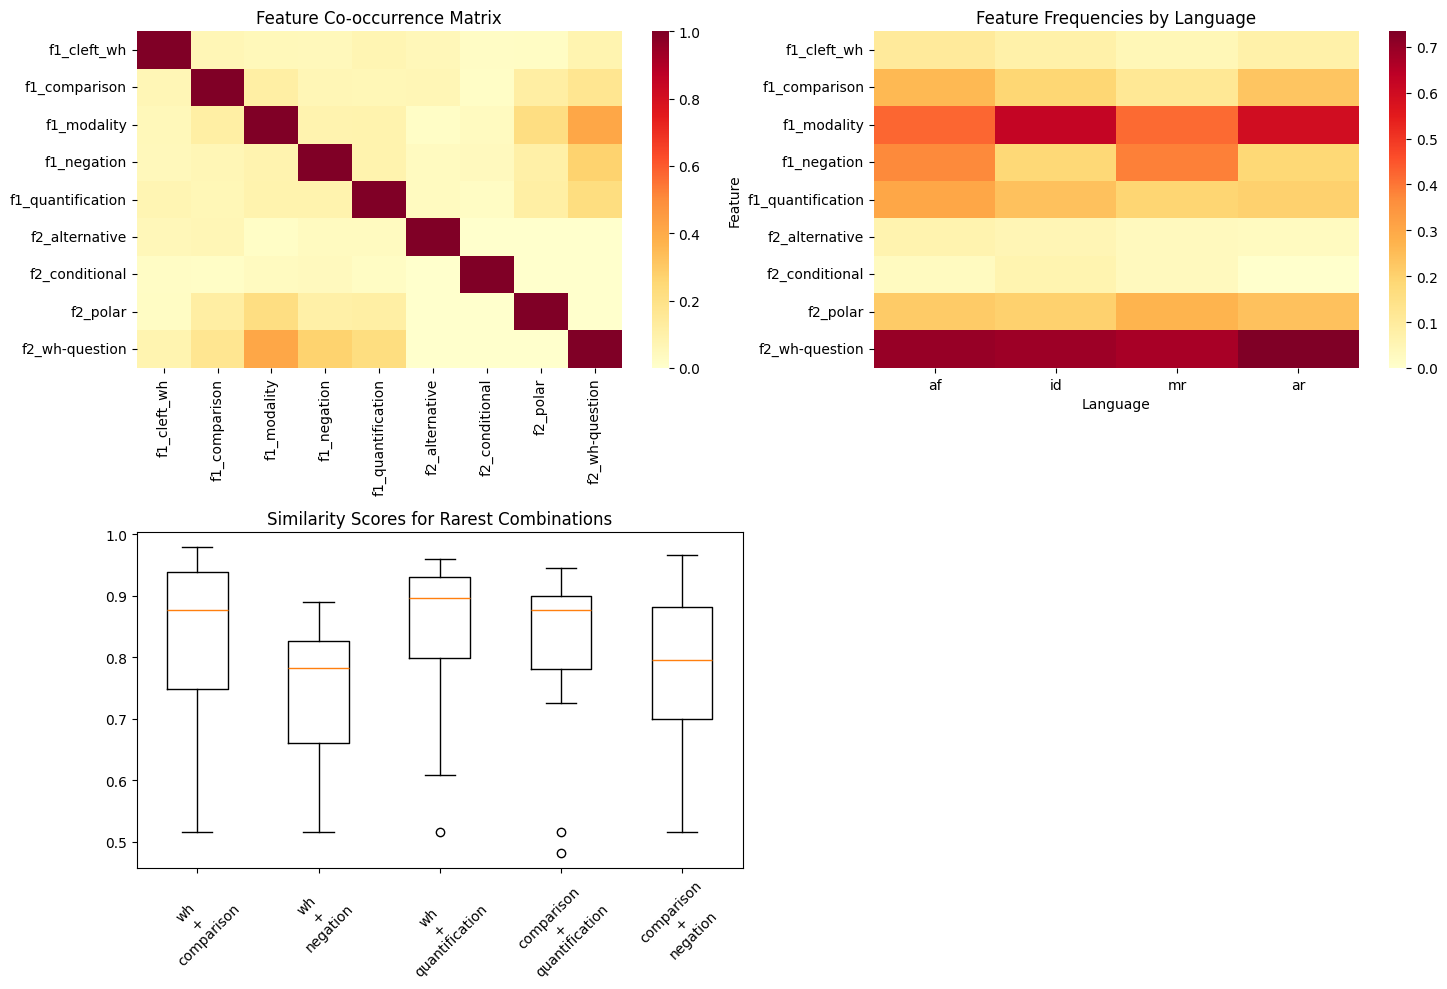


Language-specific pattern analysis:

AF specific patterns:
f1_modality: 0.422 vs 0.542 overall
f1_negation: 0.371 vs 0.255 overall

ID specific patterns:
f1_modality: 0.623 vs 0.472 overall
f1_negation: 0.181 vs 0.320 overall

MR specific patterns:
f1_comparison: 0.117 vs 0.223 overall
f1_modality: 0.416 vs 0.551 overall
f1_negation: 0.387 vs 0.242 overall

AR specific patterns:
f1_modality: 0.596 vs 0.491 overall
f1_negation: 0.183 vs 0.309 overall


In [18]:
# Load data to look for structural rarities
data = pd.read_csv('questions_with_similarities_miniLM.csv')

# Get feature columns
f1_cols = [col for col in data.columns if col.startswith('f1_')]
f2_cols = [col for col in data.columns if col.startswith('f2_')]
all_feature_cols = f1_cols + f2_cols

# Create co-occurrence matrix
co_occurrence = pd.DataFrame(0, index=all_feature_cols, columns=all_feature_cols)

# Calculate co-occurrences
print("Analyzing feature co-occurrences...")
for f1 in all_feature_cols:
    for f2 in all_feature_cols:
        # Count where both features are present
        both_present = ((data[f1] == 1) & (data[f2] == 1)).sum()
        # Count where either feature is present
        either_present = ((data[f1] == 1) | (data[f2] == 1)).sum()
        
        if either_present > 0:
            co_occurrence.loc[f1, f2] = both_present / either_present

# Find rare combinations
print("\nRarest feature combinations:")
rare_pairs = []
for f1 in all_feature_cols:
    for f2 in f1_cols[f1_cols.index(f1)+1:] if f1 in f1_cols else f2_cols:
        mask = (data[f1] == 1) & (data[f2] == 1)
        count = mask.sum()
        
        if 0 < count < len(data) * 0.05:  # less than 5%
            percentage = (count / len(data)) * 100
            # Use boolean mask properly
            mean_sim = data.loc[mask, 'cosine_similarity'].mean()
            
            rare_pairs.append({
                'feature1': f1,
                'feature2': f2,
                'count': count,
                'percentage': percentage,
                'mean_similarity': mean_sim
            })

# Display results
if rare_pairs:
    rare_df = pd.DataFrame(rare_pairs).sort_values('count')
    print("\nRare feature combinations and their similarities:")
    for _, row in rare_df.iterrows():
        print(f"{row['feature1']} + {row['feature2']}:")
        print(f"  Count: {row['count']} ({row['percentage']:.1f}%)")
        print(f"  Mean similarity: {row['mean_similarity']:.3f}")

# Visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Co-occurrence heatmap
plt.subplot(2, 2, 1)
sns.heatmap(co_occurrence, cmap='YlOrRd')
plt.title('Feature Co-occurrence Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Plot 2: Feature frequencies by language
feature_by_lang = pd.DataFrame()
for lang in data['language'].unique():
    lang_data = data[data['language'] == lang]
    feature_freqs = lang_data[all_feature_cols].mean()
    feature_by_lang[lang] = feature_freqs

plt.subplot(2, 2, 2)
sns.heatmap(feature_by_lang, cmap='YlOrRd')
plt.title('Feature Frequencies by Language')
plt.xlabel('Language')
plt.ylabel('Feature')

# Plot 3: Similarity distribution for rare combinations
if rare_pairs:
    plt.subplot(2, 2, 3)
    rare_similarities = []
    labels = []
    for _, row in rare_df.head().iterrows():
        mask = (data[row['feature1']] == 1) & (data[row['feature2']] == 1)
        sims = data.loc[mask, 'cosine_similarity']
        if not sims.empty:
            rare_similarities.append(sims)
            labels.append(f"{row['feature1'].split('_')[-1]}\n+\n{row['feature2'].split('_')[-1]}")
    
    if rare_similarities:
        plt.boxplot(rare_similarities, labels=labels)
        plt.title('Similarity Scores for Rarest Combinations')
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nLanguage-specific pattern analysis:")
for lang in data['language'].unique():
    lang_data = data[data['language'] == lang]
    print(f"\n{lang.upper()} specific patterns:")
    
    # Find features that occur significantly more/less in this language
    for feat in all_feature_cols:
        lang_freq = lang_data[feat].mean()
        other_freq = data[data['language'] != lang][feat].mean()
        if abs(lang_freq - other_freq) > 0.1:  # threshold for significance
            print(f"{feat}: {lang_freq:.3f} vs {other_freq:.3f} overall")

In [12]:
# extra processing for typological features
data = pd.read_csv('questions_with_similarities_miniLM.csv')

# Define typological features
typological_features = {
  
    'mr': {'word_order': 'SOV', 'morphology': 'agglutinative', 'wh_strategy': 'in-situ', 'q_particles': True, 'agreement': 'rich', 'verb_raising': True},

    'id': {'word_order': 'SVO', 'morphology': 'agglutinative', 'wh_strategy': 'in-situ', 'q_particles': True, 'agreement': 'limited', 'verb_raising': False},

    'ar': {'word_order': 'VSO', 'morphology': 'nonconcatenative', 'wh_strategy': 'movement', 'q_particles': True, 'agreement': 'rich', 'verb_raising': False},

    'af': {'word_order': 'V2', 'morphology': 'isolating', 'wh_strategy': 'movement', 'q_particles': False, 'agreement': 'limited', 'verb_raising': True}
}

# Add typological features to dataframe
data['word_order'] = data['language'].map(lambda x: typological_features[x]['word_order'])
data['morphology'] = data['language'].map(lambda x: typological_features[x]['morphology'])
data['wh_strategy'] = data['language'].map(lambda x: typological_features[x]['wh_strategy'])
data['q_particles'] = data['language'].map(lambda x: typological_features[x]['q_particles'])
data['agreement'] = data['language'].map(lambda x: typological_features[x]['agreement'])
data['verb_raising'] = data['language'].map(lambda x: typological_features[x]['verb_raising'])

feature_cols = [col for col in data.columns if col.startswith('f1_')]
data['feature_count'] = data[feature_cols].sum(axis=1)


In [10]:
def analyze_typological_patterns(data, features):
    """
    Analyze similarity patterns based on typological features
    """
    for feature, value_dict in features.items():
        print(f"\nAnalyzing by {feature}:")
        for type_val in set(val[feature] for val in features.values()):
            langs = [lang for lang, vals in features.items() if vals[feature] == type_val]
            relevant_data = data[data['language'].isin(langs)]
            if len(relevant_data) > 0:
                print(f"\n{type_val}:")
                print(f"Mean similarity: {relevant_data['cosine_similarity'].mean():.3f}")
                print(f"Std deviation: {relevant_data['cosine_similarity'].std():.3f}")
                print(f"Sample size: {len(relevant_data)}")
                
                # Feature-specific analysis
                for feat_col in [col for col in data.columns if col.startswith('f1_') or col.startswith('f2_')]:
                    feat_data = relevant_data[relevant_data[feat_col] == 1]
                    if len(feat_data) > 0:
                        print(f"\n{feat_col}:")
                        print(f"Mean: {feat_data['cosine_similarity'].mean():.3f}")
                        print(f"Count: {len(feat_data)}")

    return pd.DataFrame(features).T

Analysis by word order:

V2 languages:
f1_cleft_wh: mean=0.787, std=0.116, n=12
f1_comparison: mean=0.846, std=0.103, n=30
f1_modality: mean=0.819, std=0.107, n=49
f1_negation: mean=0.791, std=0.086, n=43
f1_quantification: mean=0.810, std=0.095, n=35
f2_alternative: mean=0.877, std=0.069, n=7
f2_conditional: mean=0.825, std=0.048, n=3
f2_polar: mean=0.829, std=0.097, n=25
f2_wh-question: mean=0.810, std=0.107, n=81

SVO languages:
f1_cleft_wh: mean=0.932, std=0.044, n=10
f1_comparison: mean=0.933, std=0.050, n=26
f1_modality: mean=0.926, std=0.044, n=86
f1_negation: mean=0.932, std=0.046, n=25
f1_quantification: mean=0.939, std=0.034, n=33
f2_alternative: mean=0.936, std=0.029, n=7
f2_conditional: mean=0.914, std=0.026, n=8
f2_polar: mean=0.933, std=0.042, n=28
f2_wh-question: mean=0.931, std=0.044, n=95

SOV languages:
f1_cleft_wh: mean=0.571, std=0.267, n=6
f1_comparison: mean=0.710, std=0.176, n=16
f1_modality: mean=0.716, std=0.194, n=57
f1_negation: mean=0.763, std=0.142, n=53
f1

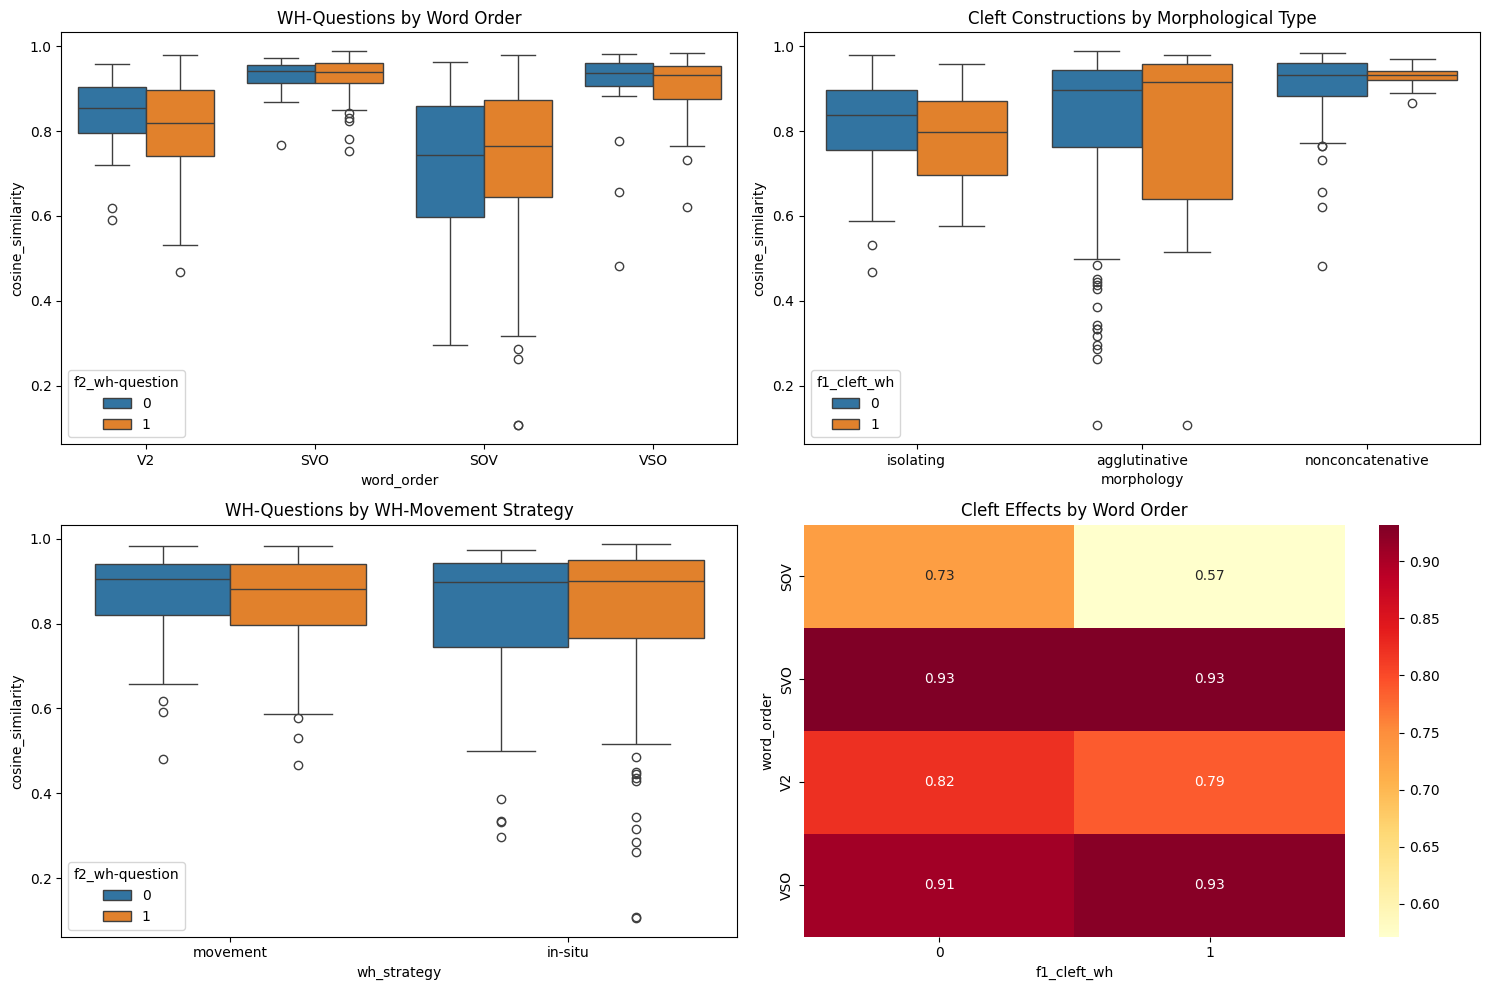


Statistical tests:
Word order effect on similarity: p=0.0000
Morphological type effect on similarity: p=0.0000


In [5]:
# word order analysis
print("Analysis by word order:")
for order in data['word_order'].unique():
    order_data = data[data['word_order'] == order]
    print(f"\n{order} languages:")
    
    # Feature analysis for this word order type
    for feat in [col for col in data.columns if col.startswith('f1_') or col.startswith('f2_')]:
        feat_data = order_data[order_data[feat] == 1]['cosine_similarity']
        if len(feat_data) > 0:
            print(f"{feat}: mean={feat_data.mean():.3f}, std={feat_data.std():.3f}, n={len(feat_data)}")

print("\nAnalysis by morphological type:")
for morph in data['morphology'].unique():
    morph_data = data[data['morphology'] == morph]
    print(f"\n{morph} languages:")
    
    # Complex feature combinations
    wh_questions = morph_data[morph_data['f2_wh-question'] == 1]['cosine_similarity']
    clefts = morph_data[morph_data['f1_cleft_wh'] == 1]['cosine_similarity']
    
    print(f"WH questions: mean={wh_questions.mean():.3f}, std={wh_questions.std():.3f}")
    print(f"Clefts: mean={clefts.mean():.3f}, std={clefts.std():.3f}")

# Visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Word order effects
plt.subplot(2, 2, 1)
sns.boxplot(data=data, x='word_order', y='cosine_similarity', hue='f2_wh-question')
plt.title('WH-Questions by Word Order')

# Plot 2: Morphological type effects
plt.subplot(2, 2, 2)
sns.boxplot(data=data, x='morphology', y='cosine_similarity', hue='f1_cleft_wh')
plt.title('Cleft Constructions by Morphological Type')

# Plot 3: WH-strategy effects
plt.subplot(2, 2, 3)
sns.boxplot(data=data, x='wh_strategy', y='cosine_similarity', hue='f2_wh-question')
plt.title('WH-Questions by WH-Movement Strategy')

# Plot 4: Feature interaction by typology
plt.subplot(2, 2, 4)
feature_type_means = data.groupby(['word_order', 'f1_cleft_wh'])['cosine_similarity'].mean().unstack()
sns.heatmap(feature_type_means, annot=True, cmap='YlOrRd')
plt.title('Cleft Effects by Word Order')

plt.tight_layout()
plt.show()

# Statistical analysis
print("\nStatistical tests:")
# Test if word order affects similarity scores
f_stat, p_val = stats.f_oneway(*[group['cosine_similarity'].values 
                                for name, group in data.groupby('word_order')])
print(f"Word order effect on similarity: p={p_val:.4f}")

# Test if morphological type affects similarity scores
f_stat, p_val = stats.f_oneway(*[group['cosine_similarity'].values 
                                for name, group in data.groupby('morphology')])
print(f"Morphological type effect on similarity: p={p_val:.4f}")



In [ ]:
# H10/13 word order - cleft constructions +

print("\nH10: Word Order Impact on Cleft Constructions")
for word_order in ['SOV', 'SVO', 'VSO', 'V2']:
    mask = (data['word_order'] == word_order) & (data['f1_cleft_wh'] == 1)
    sims = data.loc[mask, 'cosine_similarity']
    if len(sims) > 0:
        print(f"\n{word_order}:")
        print(f"Mean similarity: {sims.mean():.3f} ± {sims.std():.3f}")
        print(f"Count: {len(sims)}")

""" 
SOV languages will show significantly lower similarity scores (>0.2 difference) for cleft constructions compared to SVO languages

"""


H10: Word Order Impact on Cleft Constructions

SOV:
Mean similarity: 0.571 ± 0.267
Count: 6

SVO:
Mean similarity: 0.932 ± 0.044
Count: 10

VSO:
Mean similarity: 0.925 ± 0.032
Count: 8

V2:
Mean similarity: 0.787 ± 0.116
Count: 12


' \nSOV languages will show significantly lower similarity scores (>0.2 difference) for cleft constructions compared to SVO languages\n\n'


H14: Modality and Conditional Questions Analysis

H14a Results:
Modal + Conditional questions: 10
Modal + Conditional + Polar: 0
Expected triple combination: 1.79

H14b Results:
Modal + Conditional + WH: 0

Similarity Analysis:

Modal + Conditional similarities:
Mean: 0.872 ± 0.068

Language-specific patterns:

af:
Modal + Conditional: 2

id:
Modal + Conditional: 7

mr:
Modal + Conditional: 1

ar:
Modal + Conditional: 0


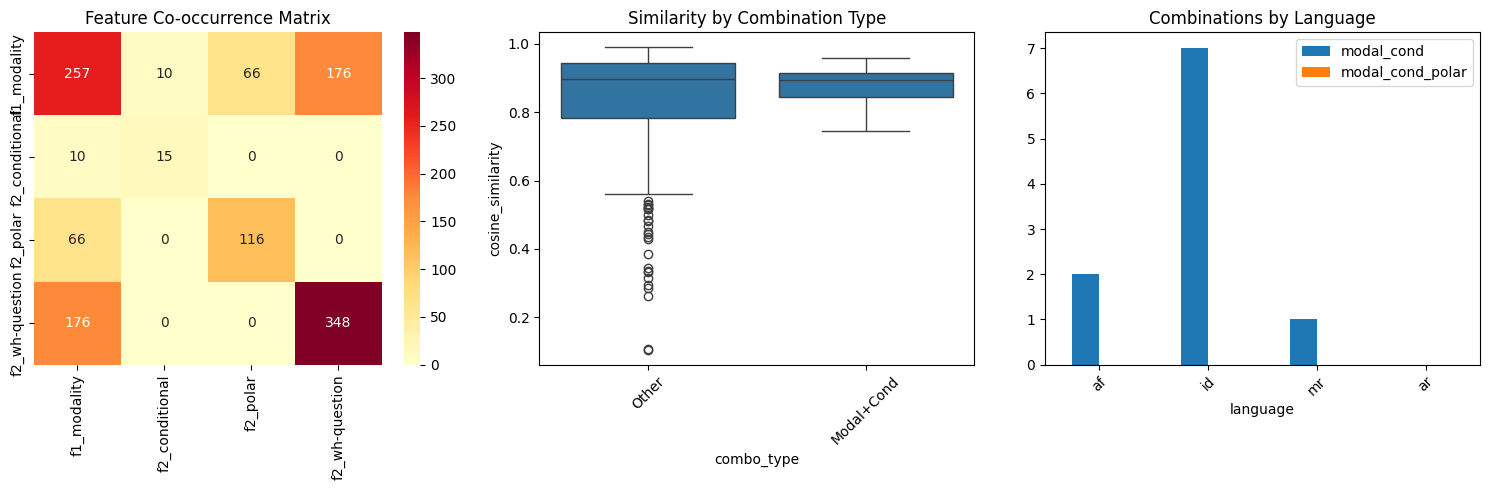


Prediction Results:
Strong prediction supported
Medium prediction supported
Weak prediction not supported


In [5]:
print("\nH14: Modality and Conditional Questions Analysis")
data = pd.read_csv('questions_with_similarities_miniLM.csv')

# H14a: Modal-Conditional-Polar incompatibility
modal_cond = ((data['f1_modality'] == 1) & (data['f2_conditional'] == 1)).sum()
modal_cond_polar = ((data['f1_modality'] == 1) & 
                    (data['f2_conditional'] == 1) & 
                    (data['f2_polar'] == 1)).sum()

# Expected frequencies
total_modal = (data['f1_modality'] == 1).sum()
total_cond = (data['f2_conditional'] == 1).sum()
total_polar = (data['f2_polar'] == 1).sum()
expected_triple = (total_modal * total_cond * total_polar) / (len(data) ** 2)

print("\nH14a Results:")
print(f"Modal + Conditional questions: {modal_cond}")
print(f"Modal + Conditional + Polar: {modal_cond_polar}")
print(f"Expected triple combination: {expected_triple:.2f}")

# H14b: Modal-Conditional-WH compatibility
modal_cond_wh = ((data['f1_modality'] == 1) & 
                 (data['f2_conditional'] == 1) & 
                 (data['f2_wh-question'] == 1)).sum()

print("\nH14b Results:")
print(f"Modal + Conditional + WH: {modal_cond_wh}")

# Similarity analysis
print("\nSimilarity Analysis:")
# For modal conditionals
mask_modal_cond = (data['f1_modality'] == 1) & (data['f2_conditional'] == 1)
if mask_modal_cond.any():
    sims_modal_cond = data[mask_modal_cond]['cosine_similarity']
    print(f"\nModal + Conditional similarities:")
    print(f"Mean: {sims_modal_cond.mean():.3f} ± {sims_modal_cond.std():.3f}")

# For modal conditional polars
mask_modal_cond_polar = mask_modal_cond & (data['f2_polar'] == 1)
if mask_modal_cond_polar.any():
    sims_modal_cond_polar = data[mask_modal_cond_polar]['cosine_similarity']
    print(f"\nModal + Conditional + Polar similarities:")
    print(f"Mean: {sims_modal_cond_polar.mean():.3f} ± {sims_modal_cond_polar.std():.3f}")

# Language-specific analysis
print("\nLanguage-specific patterns:")
for lang in data['language'].unique():
    lang_data = data[data['language'] == lang]
    lang_modal_cond = ((lang_data['f1_modality'] == 1) & 
                      (lang_data['f2_conditional'] == 1)).sum()
    print(f"\n{lang}:")
    print(f"Modal + Conditional: {lang_modal_cond}")


# Create figure
plt.figure(figsize=(15, 5))

# Plot 1: Feature co-occurrence heatmap
plt.subplot(1, 3, 1)
feature_cols = ['f1_modality', 'f2_conditional', 'f2_polar', 'f2_wh-question']
co_occurrence = pd.DataFrame(0, index=feature_cols, columns=feature_cols)  # Initialize with zeros

# Calculate co-occurrences
for f1 in feature_cols:
    for f2 in feature_cols:
        co_occurrence.loc[f1, f2] = ((data[f1] == 1) & (data[f2] == 1)).sum()

# Convert to numeric type explicitly
co_occurrence = co_occurrence.astype(float)
sns.heatmap(co_occurrence, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Feature Co-occurrence Matrix')

# Plot 2: Similarity distributions
plt.subplot(1, 3, 2)
# Create a copy of data to avoid modifying the original
plot_data = data.copy()
plot_data['combo_type'] = 'Other'

# Define masks
mask_modal_cond = (data['f1_modality'] == 1) & (data['f2_conditional'] == 1)
mask_modal_cond_polar = mask_modal_cond & (data['f2_polar'] == 1)

plot_data.loc[mask_modal_cond, 'combo_type'] = 'Modal+Cond'
plot_data.loc[mask_modal_cond_polar, 'combo_type'] = 'Modal+Cond+Polar'

sns.boxplot(data=plot_data, x='combo_type', y='cosine_similarity')
plt.title('Similarity by Combination Type')
plt.xticks(rotation=45)

# Plot 3: Language-specific patterns
plt.subplot(1, 3, 3)
lang_patterns = []
for lang in data['language'].unique():
    lang_data = data[data['language'] == lang]
    lang_patterns.append({
        'language': lang,
        'modal_cond': float(((lang_data['f1_modality'] == 1) & 
                     (lang_data['f2_conditional'] == 1)).sum()),
        'modal_cond_polar': float(((lang_data['f1_modality'] == 1) & 
                           (lang_data['f2_conditional'] == 1) & 
                           (lang_data['f2_polar'] == 1)).sum())
    })

# Create and plot DataFrame
lang_df = pd.DataFrame(lang_patterns)
lang_df.set_index('language', inplace=True)  # Set language as index
lang_df.plot(kind='bar', ax=plt.gca())
plt.title('Combinations by Language')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Check predictions
predictions = {
    'strong': modal_cond_polar == 0,  # Strong: No modal-conditional-polar
    'medium': modal_cond_polar < expected_triple * 0.5,  # Medium: Less than half expected
    'weak': modal_cond_wh > modal_cond_polar  # Weak: More WH than polar with modal-conditional
}

print("\nPrediction Results:")
for level, result in predictions.items():
    print(f"{level.capitalize()} prediction {'supported' if result else 'not supported'}")

Testing Semantic Feature Pair Incompatibilities

Negation + Alternative:
Expected co-occurrences: 5.9
Actual co-occurrences: 6
Ratio (actual/expected): 1.013

Similarity when co-occurring: 0.839 ± 0.066

Quantification + Polar:
Expected co-occurrences: 26.9
Actual co-occurrences: 24
Ratio (actual/expected): 0.892

Similarity when co-occurring: 0.840 ± 0.136

Conditional + Alternative:
Expected co-occurrences: 0.6
Actual co-occurrences: 0
Ratio (actual/expected): 0.000


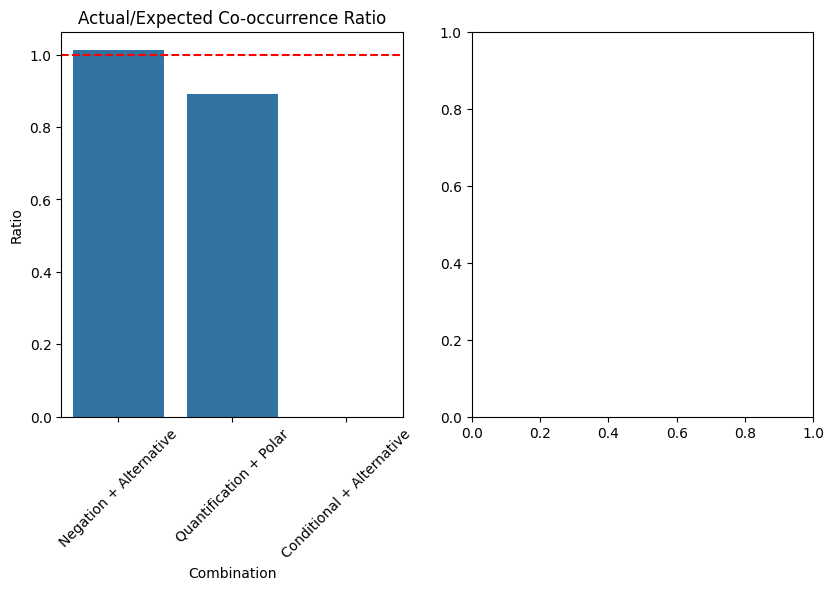

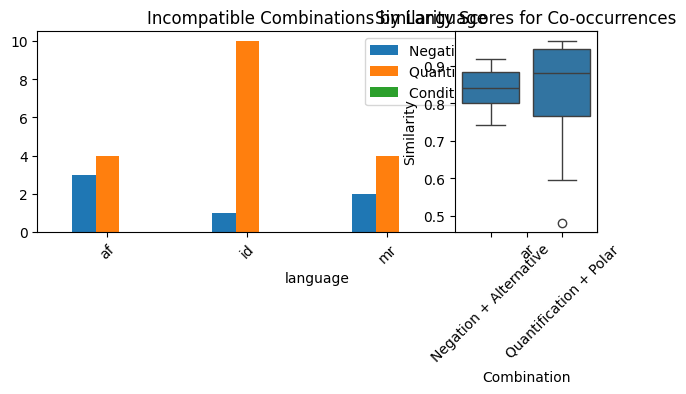


Prediction Results:

Negation + Alternative:
Strong prediction not supported
Medium prediction not supported
Weak prediction not supported

Quantification + Polar:
Strong prediction not supported
Medium prediction not supported
Weak prediction supported

Conditional + Alternative:
Strong prediction supported
Medium prediction supported
Weak prediction supported


In [ ]:


# H17 semantic incompatibility tests for: neg+alt, quant+polar, cond+alt

print("Testing Semantic Feature Pair Incompatibilities")

# Function to analyze feature pair incompatibility
def analyze_feature_pair(data, feature1, feature2, pair_name):
    # Calculate masks
    both_mask = (data[feature1] == 1) & (data[feature2] == 1)
    only_f1_mask = (data[feature1] == 1) & (data[feature2] == 0)
    only_f2_mask = (data[feature1] == 0) & (data[feature2] == 1)
    
    # Calculate frequencies
    total = len(data)
    expected = (data[feature1].mean() * data[feature2].mean() * total)
    actual = both_mask.sum()
    
    # Calculate similarities
    both_sims = data[both_mask]['cosine_similarity']
    f1_sims = data[only_f1_mask]['cosine_similarity']
    f2_sims = data[only_f2_mask]['cosine_similarity']
    
    print(f"\n{pair_name}:")
    print(f"Expected co-occurrences: {expected:.1f}")
    print(f"Actual co-occurrences: {actual}")
    print(f"Ratio (actual/expected): {actual/expected if expected > 0 else 0:.3f}")
    
    if len(both_sims) > 0:
        print(f"\nSimilarity when co-occurring: {both_sims.mean():.3f} ± {both_sims.std():.3f}")
    
    return {
        'pair': pair_name,
        'expected': expected,
        'actual': actual,
        'ratio': actual/expected if expected > 0 else 0,
        'both_mask': both_mask,
        'f1_mask': only_f1_mask,
        'f2_mask': only_f2_mask
    }

# Test each pair
pairs = [
    ('f1_negation', 'f2_alternative', 'Negation + Alternative'),
    ('f1_quantification', 'f2_polar', 'Quantification + Polar'),
    ('f2_conditional', 'f2_alternative', 'Conditional + Alternative')
]

results = []
for f1, f2, name in pairs:
    results.append(analyze_feature_pair(data, f1, f2, name))

# Visualizations
plt.figure(figsize=(15, 5))

# Plot 1: Co-occurrence ratios
plt.subplot(1, 3, 1)
ratios_df = pd.DataFrame([{
    'Combination': r['pair'],
    'Ratio': r['ratio']
} for r in results])
sns.barplot(data=ratios_df, x='Combination', y='Ratio')
plt.axhline(y=1, color='r', linestyle='--')
plt.title('Actual/Expected Co-occurrence Ratio')
plt.xticks(rotation=45)

# Plot 2: Language-specific patterns
plt.subplot(1, 3, 2)
lang_patterns = []
for lang in data['language'].unique():
    lang_data = data[data['language'] == lang]
    lang_dict = {'language': lang}
    for r in results:
        lang_dict[r['pair']] = r['both_mask'][lang_data.index].sum()
    lang_patterns.append(lang_dict)
lang_df = pd.DataFrame(lang_patterns)
lang_df.set_index('language').plot(kind='bar')
plt.title('Incompatible Combinations by Language')
plt.xticks(rotation=45)

# Plot 3: Similarity distributions
plt.subplot(1, 3, 3)
similarity_data = []
for r in results:
    both_sims = data[r['both_mask']]['cosine_similarity']
    if len(both_sims) > 0:
        similarity_data.extend([{
            'Combination': r['pair'],
            'Similarity': sim
        } for sim in both_sims])
if similarity_data:
    sim_df = pd.DataFrame(similarity_data)
    sns.boxplot(data=sim_df, x='Combination', y='Similarity')
    plt.title('Similarity Scores for Co-occurrences')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Check predictions for each pair
print("\nPrediction Results:")
for r in results:
    print(f"\n{r['pair']}:")
    predictions = {
        'strong': r['actual'] == 0,  # No co-occurrences
        'medium': r['ratio'] < 0.5,  # Less than half expected
        'weak': r['ratio'] < 1.0  # Less than expected
    }
    for level, result in predictions.items():
        print(f"{level.capitalize()} prediction {'supported' if result else 'not supported'}")